<a href="https://colab.research.google.com/github/swethaukkarde/Neural-networks-and-deep-learning/blob/main/Exp_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 39ms/step - accuracy: 0.4825 - loss: 1.4469 - val_accuracy: 0.5893 - val_loss: 1.1807
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.6136 - loss: 1.0973 - val_accuracy: 0.6204 - val_loss: 1.1169
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.6612 - loss: 0.9746 - val_accuracy: 0.6614 - val_loss: 0.9824
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.6880 - loss: 0.8869 - val_accuracy: 0.6714 - val_loss: 0.9619
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 39ms/step - accuracy: 0.7156 - loss: 0.8224 - val_accuracy: 0.6746 - val_loss: 0.9444
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6746 - loss: 0.9444
Test Accuracy: 0.6746000051498413


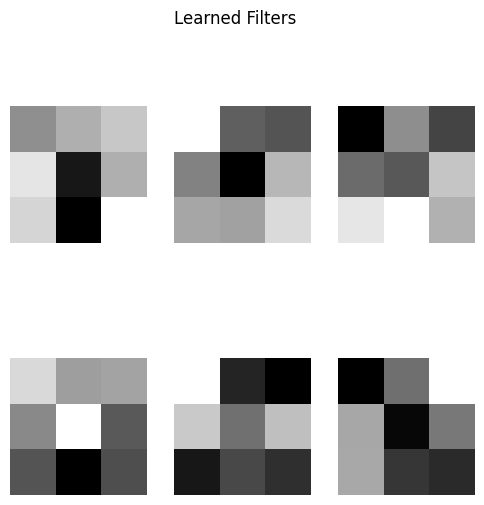

In [1]:
# Problem Statement:
# You are hired by a toy manufacturing company to classify 10 types of toy images.
# Train a CNN on CIFAR-10 and visualize the filters to explain how the model learns
# shapes, lines, and textures.

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Load CIFAR-10 Dataset
# -------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train, x_test = x_train/255.0, x_test/255.0

# -------------------------------
# Step 2: Build CNN Model
# -------------------------------
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# -------------------------------
# Step 3: Train Model
# -------------------------------
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# -------------------------------
# Step 4: Evaluate
# -------------------------------
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

# -------------------------------
# Step 5: Visualize Filters
# -------------------------------
filters, _ = model.layers[0].get_weights()

plt.figure(figsize=(6,6))
for i in range(6):
    f = filters[:,:,:,i]
    plt.subplot(2,3,i+1)
    plt.imshow(f[:,:,0], cmap='gray')
    plt.axis('off')

plt.suptitle("Learned Filters")
plt.show()